In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Preprocessing Data

In [22]:
#importing data
df = pd.read_csv("nmibc_data.csv")

#remove histology columns
df = df.drop(columns=[
    "GP Infiltrative",
    "Gp Trabecular",
    "Gp Pseudoglandular",
    "Gp Glandular",
    "Pvh Micropapillary",
    "Pvh Adenocarcinoma",
    "Pvh Smallcell",
    "Pvh Nested",
    "Pvh Glandular",
    "Pvh Sarcomatoid",
    "Pvh Acinar",
    "Pvh Other",
    "Pvh Poorlydifferentiated",
    "Svh Poorlydifferentiated",
    "Svh Adenocarcinoma",
    "Svh Nested",
    "Svh Micropapillary",
    "Svh Sarcomatoid",
    "Svh Other",
    "Svh Glandular",
    "Svh Acinar",
    "Svh Smallcell",
    "Pvh Squamous",
    "Svh Squamous"
])

print(df.columns)
#view data
print(df.head())


#handle missing values
#check which features are missing values
print(df.isnull().sum())

#remove rows with missing values in columns with <5% of total rows missing values ("Sample Grade")
df = df.dropna(subset=["Sample Grade"])

#fill rows with unknown in columns with remaining missing values with "unknown"
df["Specimen Available"] = df["Specimen Available"].fillna("unknown")
df["BCG Instillations"] = df["BCG Instillations"].fillna("unknown")
df["Urothelial Like"] = df["Urothelial Like"].fillna("unknown")

#normalize data?
#format?
#subset data?

Index(['Patient_ID', 'Sample Id', 'Proteomics Id', 'Proteomics Sample',
       'Proteomics Batch', 'Proteomics Set', 'Proteomics Stage',
       'Total Abundance', 'Gene Of Interest', 'Immuno Value', 'TURBT Number',
       'TMA Number', 'Associated CIS', 'Muscularis Propria Present', 'LVI YN',
       'Urothelial Like', 'Sample Stage', 'Sample Grade', 'Project Use',
       'Drug Type', 'BCG Type', 'BCG Instillations', 'Treatment YN',
       'Patient Dem ID', 'Collection Type', 'Treatment Id', 'Subtype',
       'Specimen Available', 'Collection TBL ID', 'Lifetime Number Of TURBTs',
       'Recurrent Tumors', 'Sex', 'Hospital', 'Primary Diagnosis',
       'Patient Age Diagnosis'],
      dtype='object')
  Patient_ID  Sample Id Proteomics Id  Proteomics Sample  Proteomics Batch  \
0  KHSC-0001        879         879-T                  5                 4   
1  KHSC-0002         22          22-T                  3                 6   
2  KHSC-0003        769         769-T                  1  

## Exploratory Data Analysis (EDA)

### Univariate

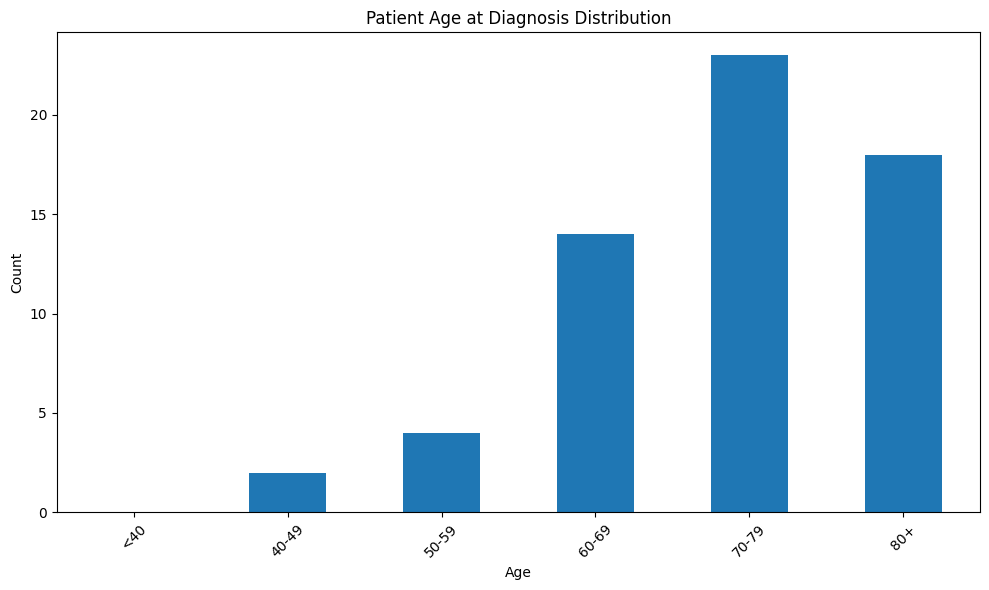

In [23]:
# patient demographics

# age
# split ages into groups
#max_age = df["Patient Age Diagnosis"].max() #might be too complicated
bins = [0, 40, 50, 60, 70, 80, 100]
labels = ["<40", "40-49", "50-59", "60-69", "70-79", "80+"]

df["Age Group"] = pd.cut(df["Patient Age Diagnosis"], bins=bins, labels=labels, right=False)

age_counts = df["Age Group"].value_counts().sort_index()

# plot
plt.figure(figsize=(10, 6))
age_counts.plot(kind="bar")

plt.title("Patient Age at Diagnosis Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

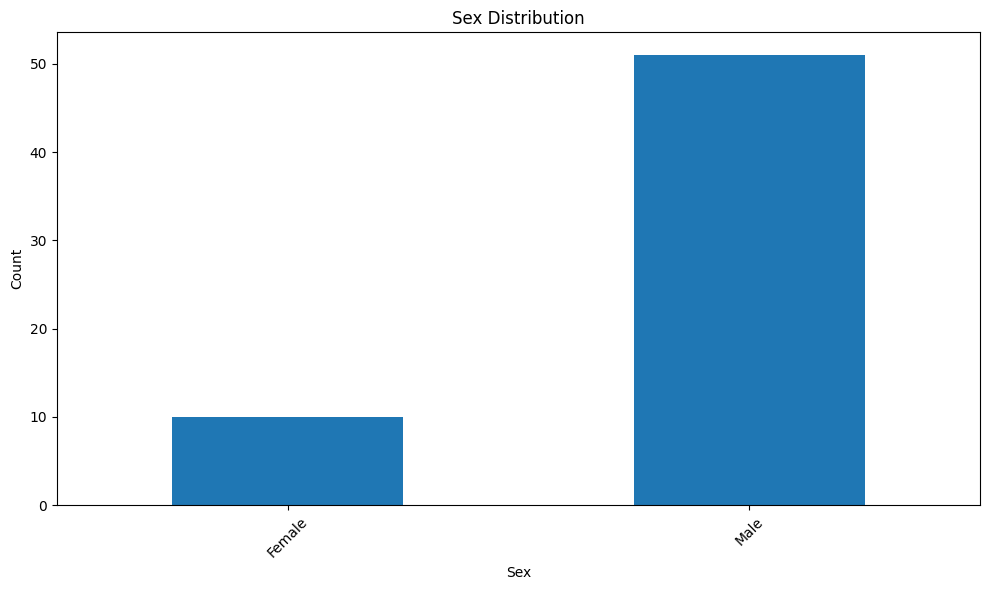

In [24]:
#sex
sex_counts = df["Sex"].value_counts().sort_index()

# plot
plt.figure(figsize=(10, 6))
sex_counts.plot(kind="bar")

plt.title("Sex Distribution")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

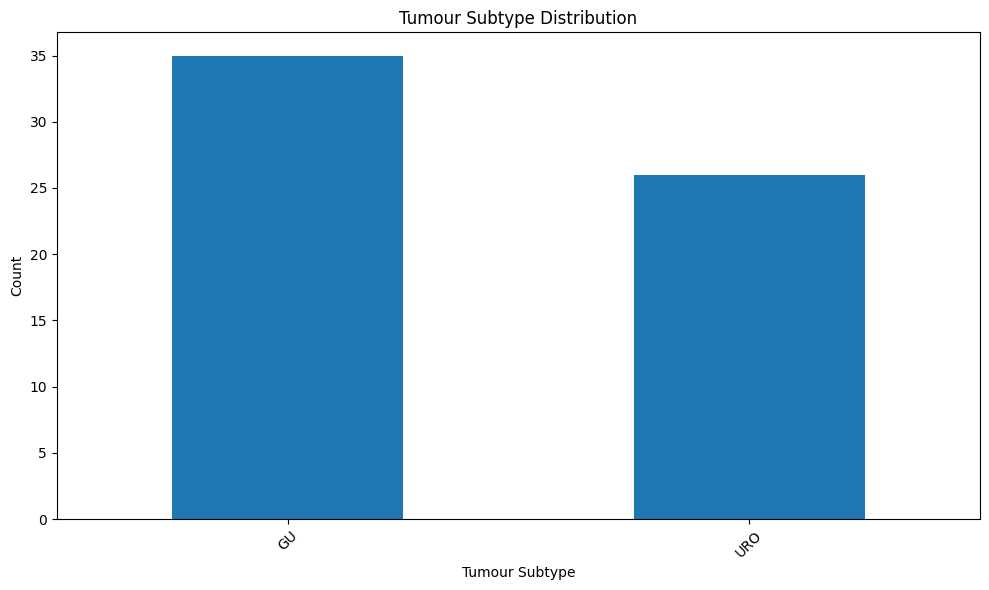

In [25]:
# tumour [statistics/insight]
# tumour subtype
subtype_counts = df["Subtype"].value_counts().sort_index()

# plot
plt.figure(figsize=(10, 6))
subtype_counts.plot(kind="bar")

plt.title("Tumour Subtype Distribution")
plt.xlabel("Tumour Subtype")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

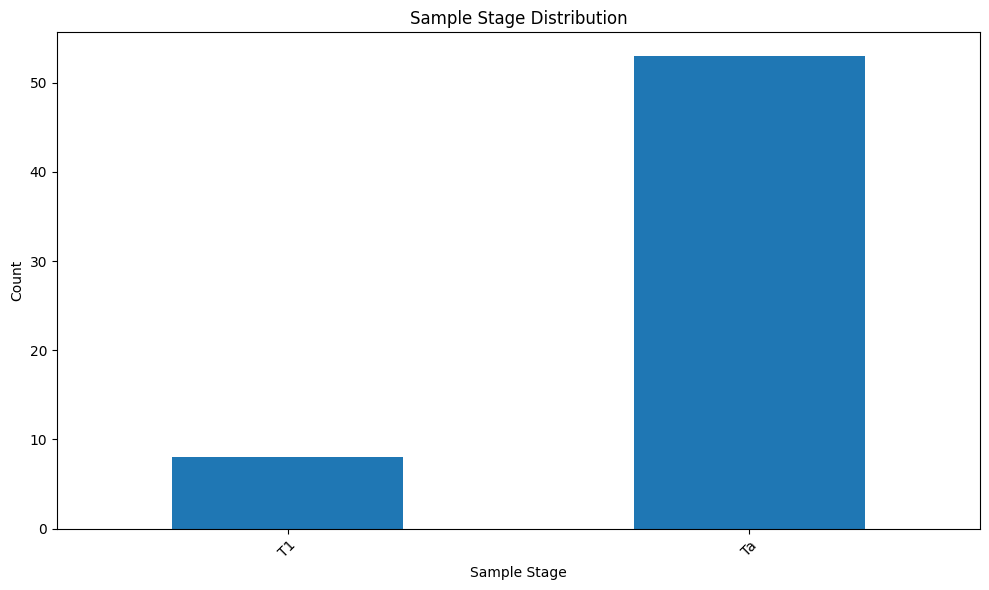

In [26]:
# sample stage
sample_stage_counts = df["Sample Stage"].value_counts().sort_index()

# plot
plt.figure(figsize=(10, 6))
sample_stage_counts.plot(kind="bar")

plt.title("Sample Stage Distribution")
plt.xlabel("Sample Stage")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

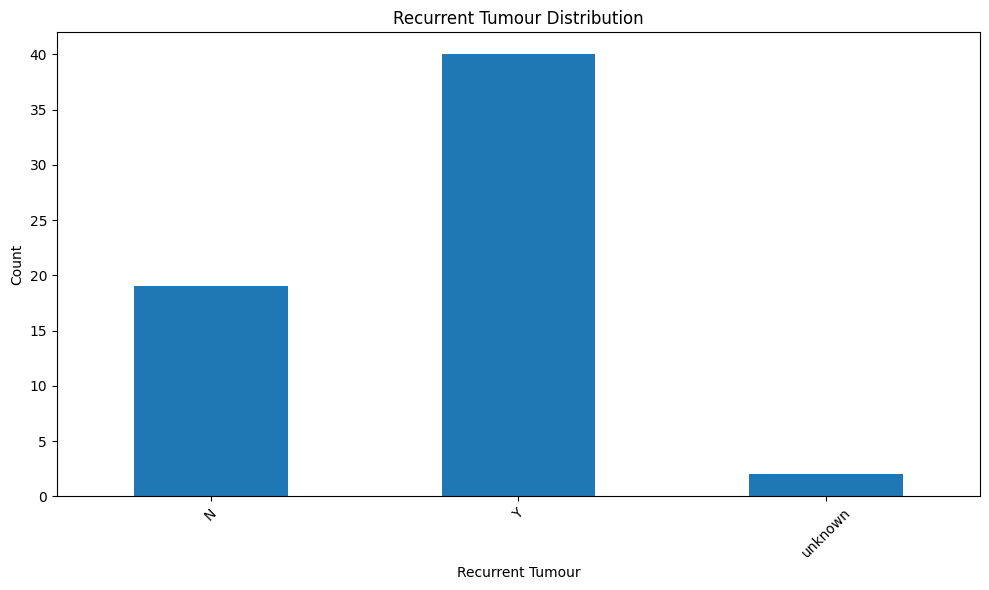

In [39]:
# recurrent tumours
sample_stage_counts = df["Recurrent Tumors"].value_counts().sort_index()

# plot
plt.figure(figsize=(10, 6))
sample_stage_counts.plot(kind="bar")

plt.title("Recurrent Tumour Distribution")
plt.xlabel("Recurrent Tumour")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Multivariate

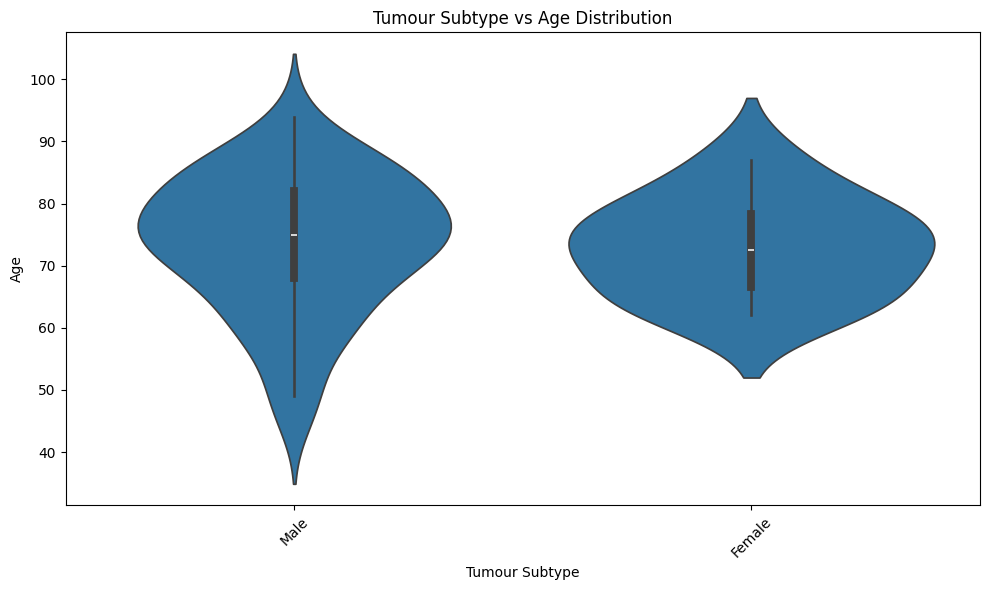

In [40]:
#age vs sex
plt.figure(figsize=(10, 6))

sns.violinplot(data=df, x="Sex", y="Patient Age Diagnosis")

plt.title("Tumour Subtype vs Age Distribution")
plt.xlabel("Tumour Subtype")
plt.ylabel("Age")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

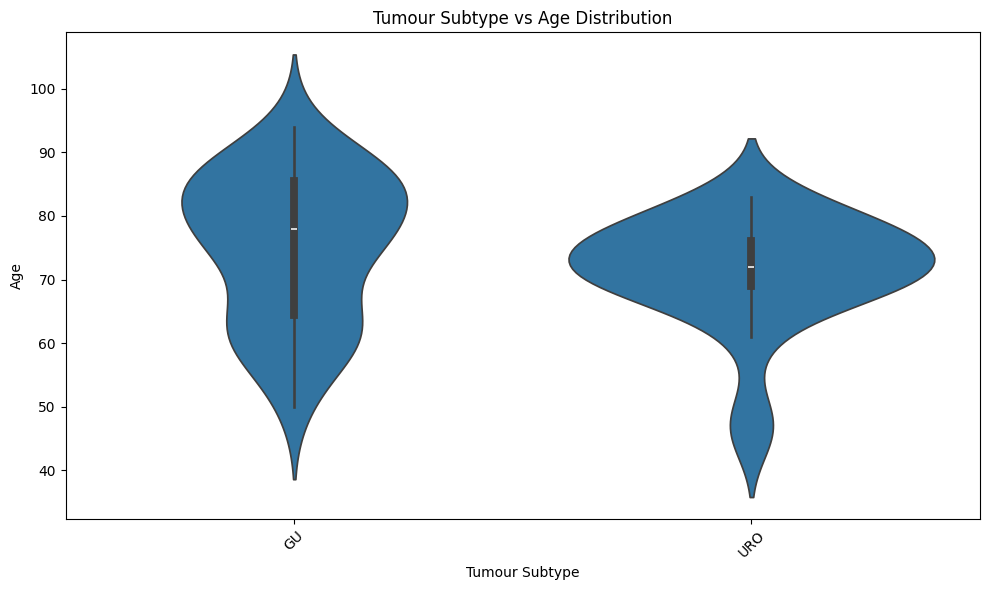

In [ ]:
#tumour subtype vs age
plt.figure(figsize=(10, 6))

sns.violinplot(data=df, x="Subtype", y="Patient Age Diagnosis")

plt.title("Tumour Subtype vs Age Distribution")
plt.xlabel("Tumour Subtype")
plt.ylabel("Age")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

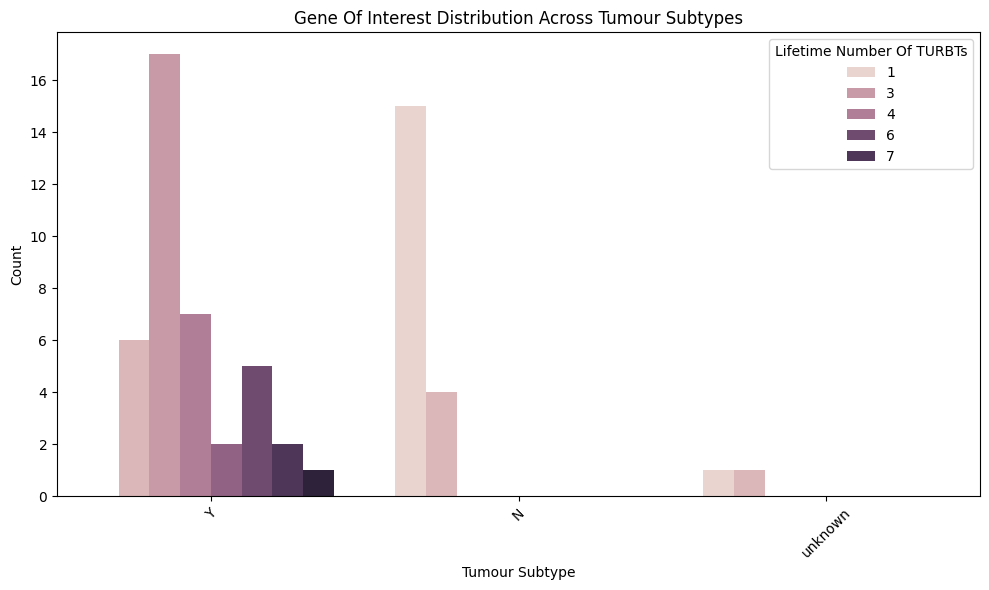

In [37]:
#tumour subtype vs gene of interest
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="Recurrent Tumors",
    hue="Lifetime Number Of TURBTs"
)


plt.title("Gene Of Interest Distribution Across Tumour Subtypes")
plt.xlabel("Tumour Subtype")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Analysis

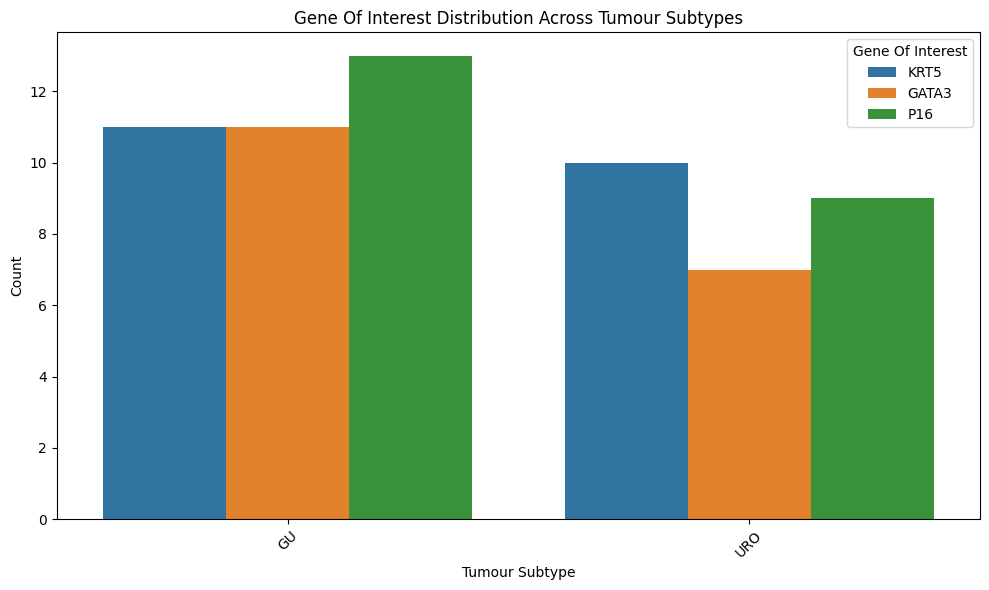

In [35]:
#tumour subtype vs gene of interest
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="Subtype",
    hue="Gene Of Interest"
)

plt.title("Gene Of Interest Distribution Across Tumour Subtypes")
plt.xlabel("Tumour Subtype")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Survival Analysis
- Duration based on multiple dates